In [2]:
# Cell 0
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    pass


Mounted at /content/drive


In [3]:
# Cell 1
!pip install pmdarima prophet --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 36.4 MB/s eta 0:00:00


In [4]:
# Cell 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from prophet import Prophet
from scipy.stats import norm as _norm

from pmdarima import auto_arima

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COUNTRIES = ['Bangladesh', 'India', 'Pakistan']

BASE_DIR        = os.getcwd()
LOCAL_DATA_PATH = os.path.join(BASE_DIR, 'owid-covid-data.csv')
LOCAL_OUT_DIR   = os.path.join(BASE_DIR, 'outputs')

if os.path.exists(LOCAL_DATA_PATH):
    DATA_PATH = LOCAL_DATA_PATH
    OUT_DIR   = LOCAL_OUT_DIR
else:
    DATA_PATH = '/content/drive/MyDrive/CSE427/Time Series Forecasting/owid-covid-data.csv'
    OUT_DIR   = '/content/drive/MyDrive/CSE427/Time Series Forecasting'

TRAIN_RATIO      = 0.80
FORECAST_HORIZON = 180
print(f"DATA_PATH     : {DATA_PATH}")
print(f"OUT_DIR       : {OUT_DIR}")


DATA_PATH     : /content/drive/MyDrive/CSE427/Time Series Forecasting/owid-covid-data.csv
OUT_DIR       : /content/drive/MyDrive/CSE427/Time Series Forecasting


In [5]:
# Cell 3
os.makedirs(OUT_DIR, exist_ok=True)

df_raw = pd.read_csv(
    DATA_PATH,
    usecols=['location', 'date', 'total_vaccinations'],
    parse_dates=['date']
)
df_raw = df_raw[df_raw['location'].isin(COUNTRIES)].copy()
df_raw.sort_values(['location', 'date'], inplace=True)
df_raw.reset_index(drop=True, inplace=True)

print(df_raw.shape)
print(df_raw.dtypes)
df_raw.head(10)


(4161, 3)
location                      object
date                  datetime64[ns]
total_vaccinations           float64
dtype: object


,location,date,total_vaccinations
0,Bangladesh,2020-01-03,NaN
1,Bangladesh,2020-01-04,NaN
2,Bangladesh,2020-01-05,NaN
3,Bangladesh,2020-01-06,NaN
4,Bangladesh,2020-01-07,NaN
5,Bangladesh,2020-01-08,NaN
6,Bangladesh,2020-01-09,NaN
7,Bangladesh,2020-01-10,NaN
8,Bangladesh,2020-01-11,NaN
9,Bangladesh,2020-01-12,NaN


In [6]:
# Cell 4
for country in COUNTRIES:
    sub = df_raw[df_raw['location'] == country]
    print(
        f"{country}: {len(sub)} rows | "
        f"{sub['date'].min().date()} to {sub['date'].max().date()}"
    )


Bangladesh: 1386 rows | 2020-01-03 to 2023-10-19
India: 1390 rows | 2020-01-03 to 2023-10-23
Pakistan: 1385 rows | 2020-01-03 to 2023-10-18


In [7]:
# Cell 5
null_counts    = df_raw.groupby('location')['total_vaccinations'].apply(lambda x: x.isnull().sum())
present_counts = df_raw.groupby('location')['total_vaccinations'].count()
missing_pct    = (null_counts / (null_counts + present_counts) * 100).round(2)

null_audit = pd.DataFrame({
    'missing'     : null_counts,
    'present'     : present_counts,
    'missing_pct' : missing_pct
})
print(null_audit.to_string())


            missing  present  missing_pct
location                                 
Bangladesh      903      483        65.15
India           405      985        29.14
Pakistan       1007      378        72.71


In [8]:
# Cell 6
country_data = {}

for country in COUNTRIES:
    subset = df_raw[df_raw['location'] == country][['date', 'total_vaccinations']].copy()
    subset = subset.dropna(subset=['total_vaccinations'])
    subset = subset.drop_duplicates(subset=['date'])
    subset = subset.set_index('date').sort_index()
    subset = subset.asfreq('D')
    subset['total_vaccinations'] = subset['total_vaccinations'].interpolate(method='linear')
    country_data[country] = subset

for country, df in country_data.items():
    n_null = df['total_vaccinations'].isnull().sum()
    print(f"{country}: {len(df)} observations after preprocessing | {n_null} remaining nulls")


Bangladesh: 996 observations after preprocessing | 0 remaining nulls
India: 1012 observations after preprocessing | 0 remaining nulls
Pakistan: 967 observations after preprocessing | 0 remaining nulls


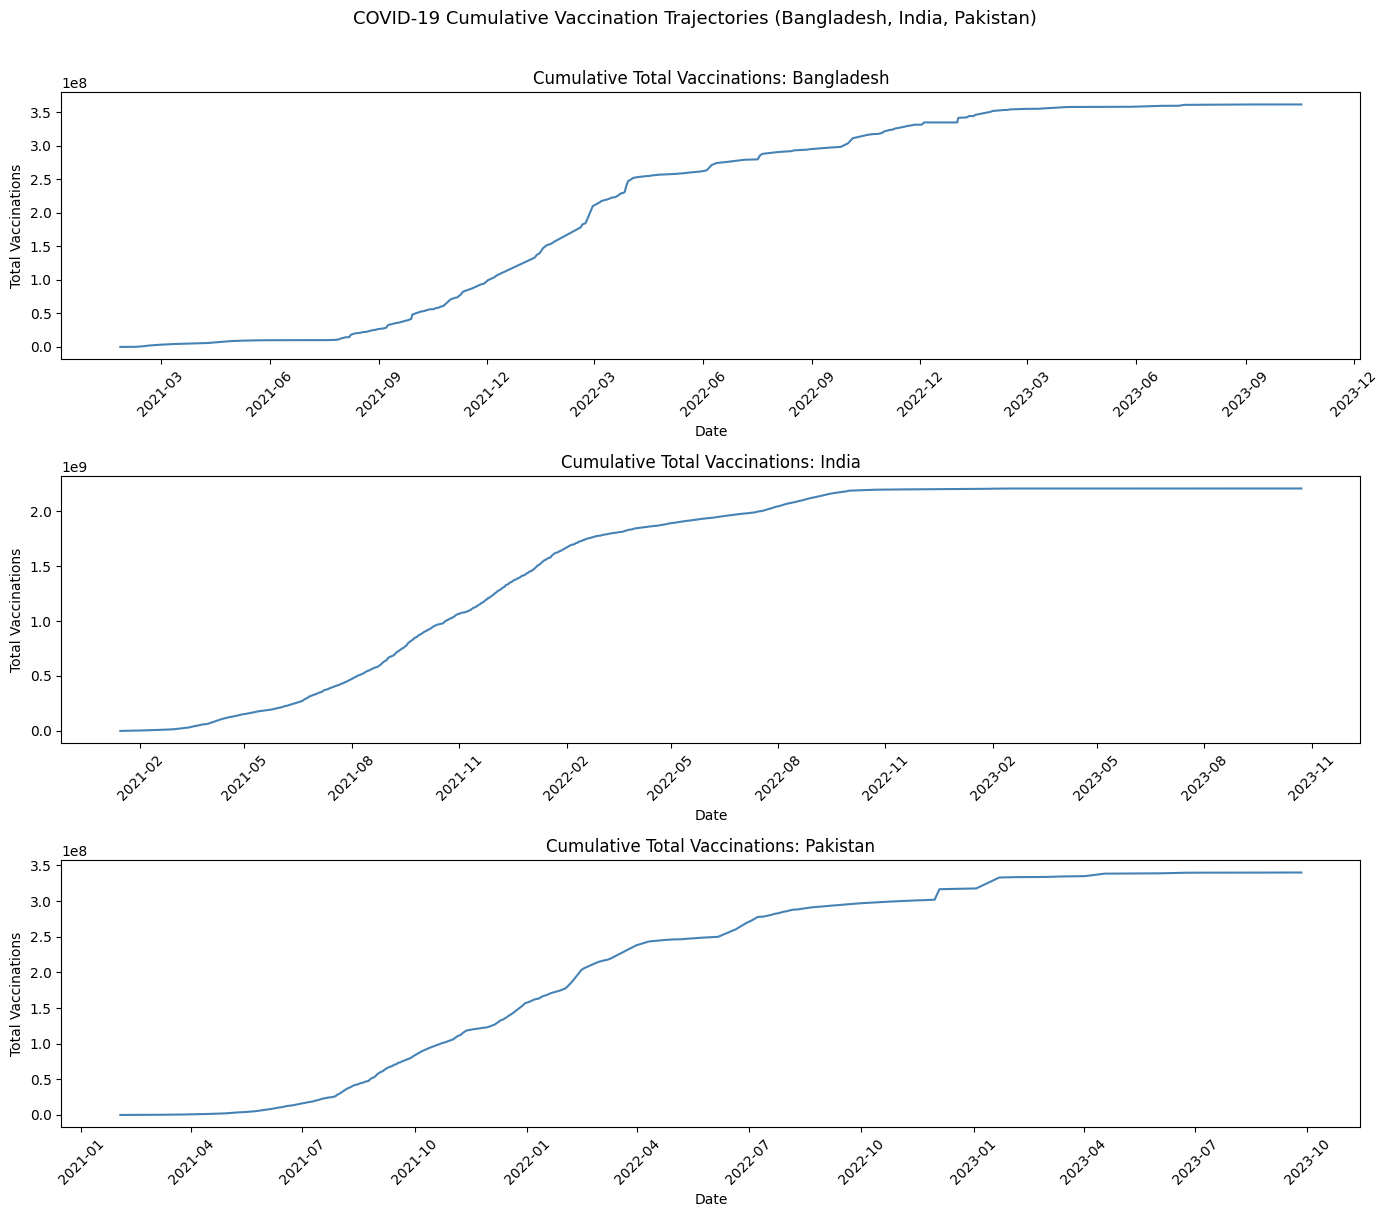

In [9]:
# Cell 7
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, country in zip(axes, COUNTRIES):
    df = country_data[country]
    ax.plot(df.index, df['total_vaccinations'], linewidth=1.5, color='steelblue')
    ax.set_title(f'Cumulative Total Vaccinations: {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Vaccinations')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('COVID-19 Cumulative Vaccination Trajectories (Bangladesh, India, Pakistan)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_01_raw_series.png'), dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Cell 8
def run_stationarity(series, label):
    adf_stat, adf_p, adf_lags, *_ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_p, kpss_lags, _ = kpss(series.dropna(), regression='c', nlags='auto')
    adf_conclusion  = 'Stationary'     if adf_p  < 0.05 else 'Non-Stationary'
    kpss_conclusion = 'Non-Stationary' if kpss_p < 0.05 else 'Stationary'
    return {
        'Series'          : label,
        'ADF Stat'        : round(adf_stat, 4),
        'ADF p'           : round(adf_p, 4),
        'ADF Conclusion'  : adf_conclusion,
        'KPSS Stat'       : round(kpss_stat, 4),
        'KPSS p'          : round(kpss_p, 4),
        'KPSS Conclusion' : kpss_conclusion
    }

stationarity_records = []

for country in COUNTRIES:
    series = country_data[country]['total_vaccinations']
    stationarity_records.append(run_stationarity(series,                 f'{country} | Level'))
    stationarity_records.append(run_stationarity(series.diff().dropna(), f'{country} | First Diff'))

stat_df = pd.DataFrame(stationarity_records).set_index('Series')
print("Stationarity Tests (ADF: H0=unit root present | KPSS: H0=series is stationary)\n")
print(stat_df.to_string())
print("Note: KPSS p-values are bounded to [0.01, 0.10] by statsmodels; a value of 0.01 means p ≤ 0.01.")
print()
print("Interpretation note: India shows a conflict — ADF concludes the level is stationary"
      " (p=0.031) while KPSS concludes non-stationary, and the first difference is"
      " non-stationary under both tests. This likely reflects structural breaks or"
      " plateauing in India's vaccination roll-out. auto_arima's data-driven selection"
      " (d=2) is preferred over the conflicting manual test results.")


Stationarity Tests (ADF: H0=unit root present | KPSS: H0=series is stationary)

                         ADF Stat   ADF p  ADF Conclusion  KPSS Stat  KPSS p KPSS Conclusion
Series                                                                                      
Bangladesh | Level        -1.4367  0.5646  Non-Stationary     4.8701    0.01  Non-Stationary
Bangladesh | First Diff   -4.6307  0.0001      Stationary     1.0873    0.01  Non-Stationary
India | Level             -3.0424  0.0311      Stationary     4.5261    0.01  Non-Stationary
India | First Diff        -1.3262  0.6171  Non-Stationary     2.5427    0.01  Non-Stationary
Pakistan | Level          -1.9105  0.3271  Non-Stationary     4.7001    0.01  Non-Stationary
Pakistan | First Diff     -5.3868  0.0000      Stationary     1.3074    0.01  Non-Stationary
Note: KPSS p-values are bounded to [0.01, 0.10] by statsmodels; a value of 0.01 means p ≤ 0.01.

Interpretation note: India shows a conflict — ADF concludes the level is statio

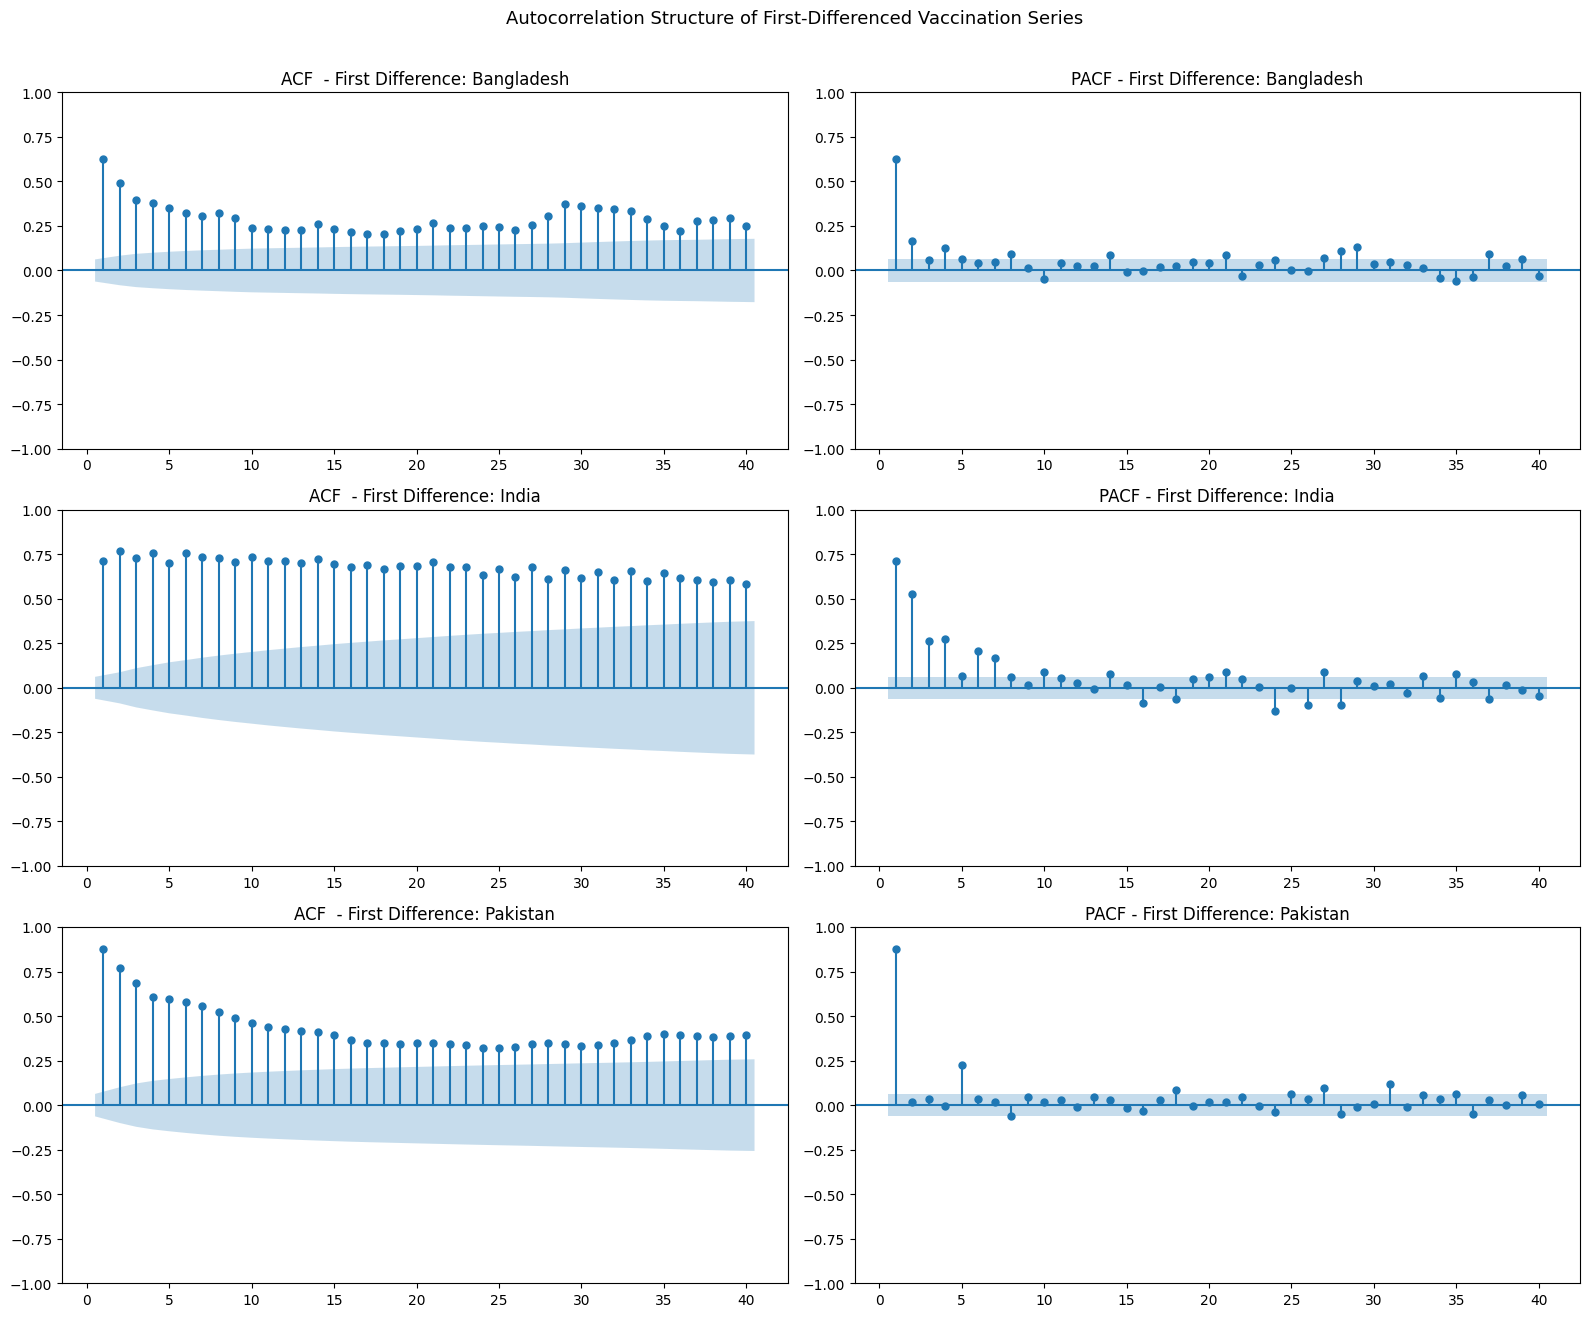

In [11]:
# Cell 9
fig, axes = plt.subplots(3, 2, figsize=(16, 13))

for i, country in enumerate(COUNTRIES):
    series_diff = country_data[country]['total_vaccinations'].diff().dropna()
    plot_acf(series_diff,  lags=40, ax=axes[i, 0],
             title=f'ACF  - First Difference: {country}', zero=False)
    plot_pacf(series_diff, lags=40, ax=axes[i, 1],
              title=f'PACF - First Difference: {country}', zero=False)

plt.suptitle('Autocorrelation Structure of First-Differenced Vaccination Series',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_02_acf_pacf.png'), dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# Cell 10
splits = {}

for country in COUNTRIES:
    df      = country_data[country]
    n       = len(df)
    split_n = int(n * TRAIN_RATIO)
    train   = df.iloc[:split_n].copy()
    test    = df.iloc[split_n:].copy()
    splits[country] = {'train': train, 'test': test}
    print(
        f"{country}: "
        f"train [{train.index[0].date()} -- {train.index[-1].date()}] n={len(train)} | "
        f"test  [{test.index[0].date()}  -- {test.index[-1].date()}]  n={len(test)}"
    )


Bangladesh: train [2021-01-26 -- 2023-04-01] n=796 | test  [2023-04-02  -- 2023-10-18]  n=200
India: train [2021-01-15 -- 2023-04-03] n=809 | test  [2023-04-04  -- 2023-10-23]  n=203
Pakistan: train [2021-02-02 -- 2023-03-16] n=773 | test  [2023-03-17  -- 2023-09-26]  n=194


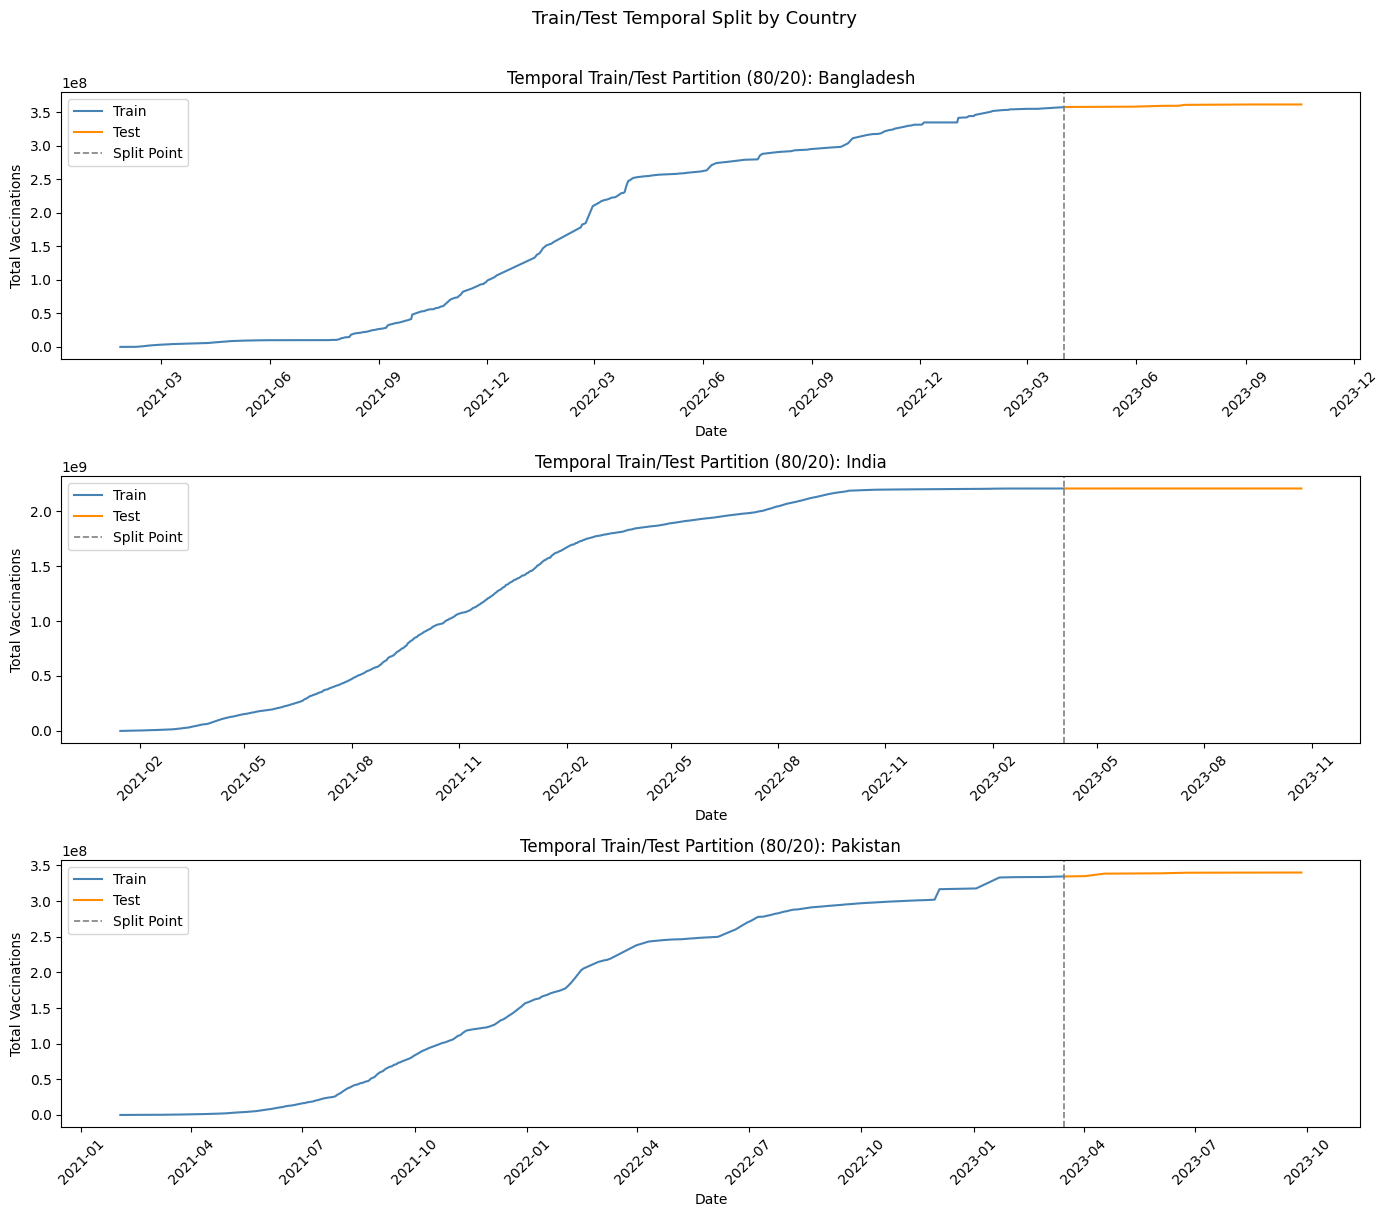

In [13]:
# Cell 11
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, country in zip(axes, COUNTRIES):
    train = splits[country]['train']
    test  = splits[country]['test']
    ax.plot(train.index, train['total_vaccinations'],
            label='Train', color='steelblue', linewidth=1.5)
    ax.plot(test.index,  test['total_vaccinations'],
            label='Test',  color='darkorange', linewidth=1.5)
    ax.axvline(x=train.index[-1], color='gray', linestyle='--',
               linewidth=1.2, label='Split Point')
    ax.set_title(f'Temporal Train/Test Partition (80/20): {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Vaccinations')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Train/Test Temporal Split by Country', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_03_train_test_split.png'), dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Cell 12
scalers       = {}
scaled_splits = {}

for country in COUNTRIES:
    scaler = StandardScaler()
    train  = splits[country]['train'][['total_vaccinations']]
    test   = splits[country]['test'][['total_vaccinations']]

    train_scaled = pd.DataFrame(
        scaler.fit_transform(train),
        index=train.index,
        columns=['total_vaccinations']
    )
    test_scaled = pd.DataFrame(
        scaler.transform(test),
        index=test.index,
        columns=['total_vaccinations']
    )

    scalers[country]       = scaler
    scaled_splits[country] = {'train': train_scaled, 'test': test_scaled}
    print(f"{country}: fit mean={scaler.mean_[0]:.4e}, std={scaler.scale_[0]:.4e}")


Bangladesh: fit mean=1.7562e+08, std=1.3458e+08
India: fit mean=1.3634e+09, std=8.2180e+08
Pakistan: fit mean=1.7515e+08, std=1.2196e+08


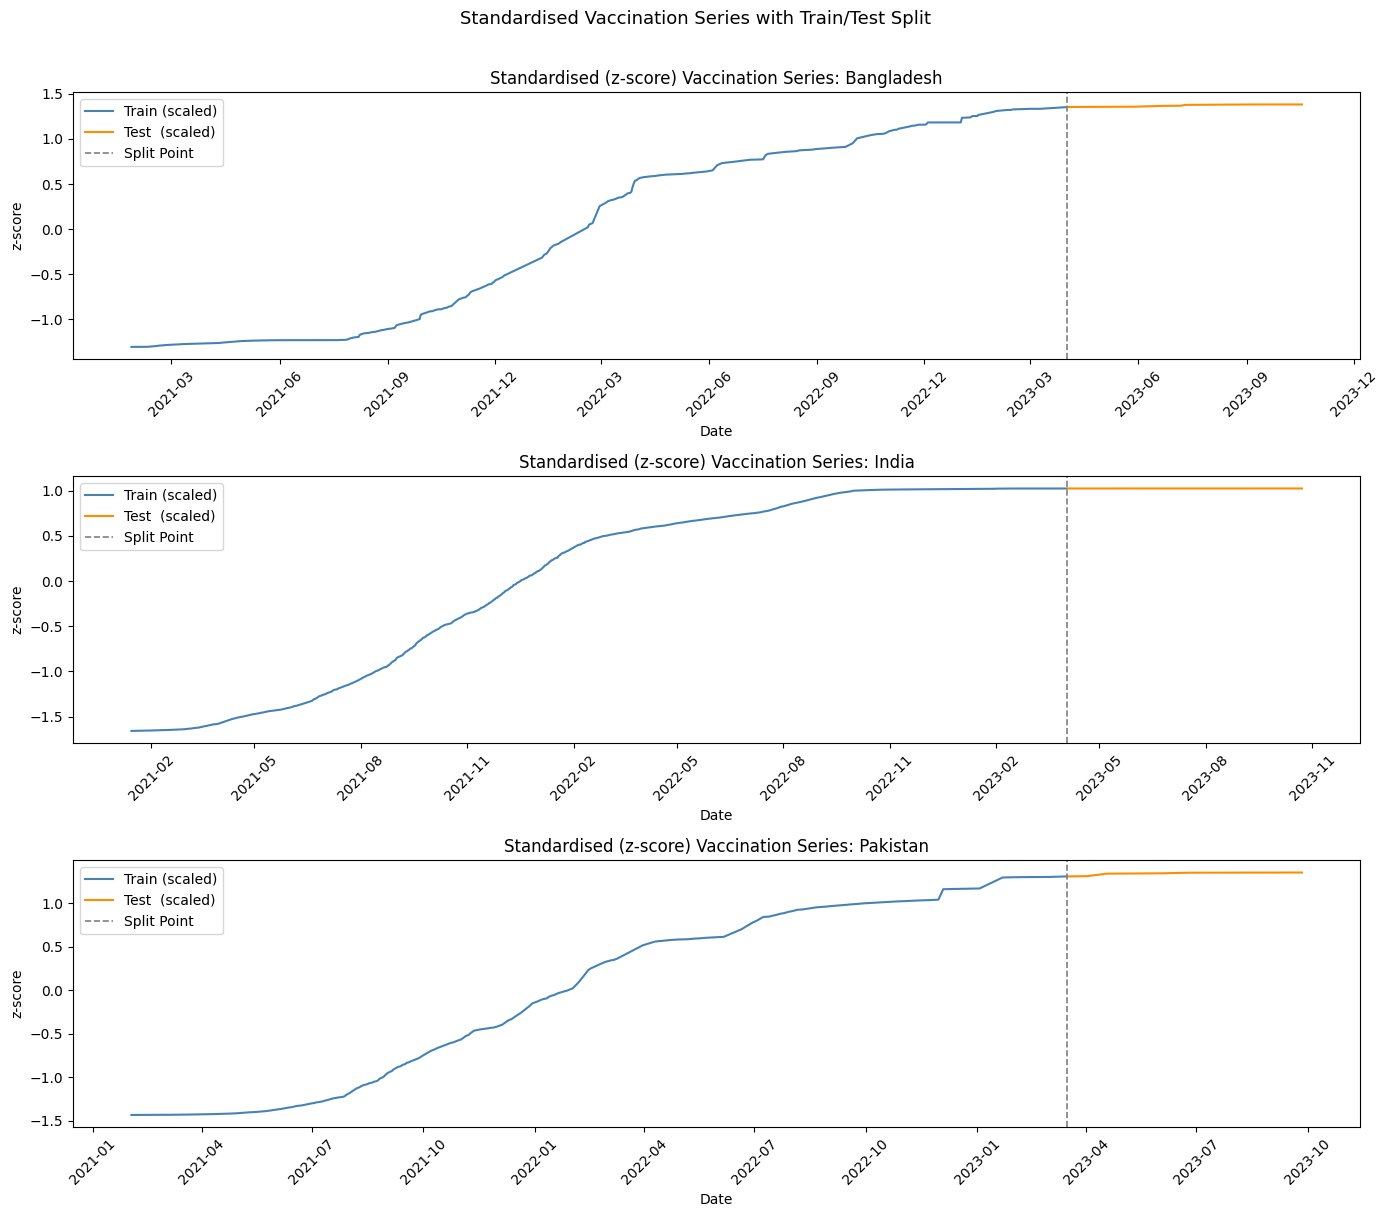

In [15]:
# Cell 12b
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, country in zip(axes, COUNTRIES):
    train_sc = scaled_splits[country]['train']['total_vaccinations']
    test_sc  = scaled_splits[country]['test']['total_vaccinations']
    ax.plot(train_sc.index, train_sc.values, label='Train (scaled)', color='steelblue', linewidth=1.5)
    ax.plot(test_sc.index,  test_sc.values,  label='Test  (scaled)', color='darkorange', linewidth=1.5)
    ax.axvline(x=train_sc.index[-1], color='gray', linestyle='--', linewidth=1.2, label='Split Point')
    ax.set_title(f'Standardised (z-score) Vaccination Series: {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('z-score')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Standardised Vaccination Series with Train/Test Split', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_04_scaled_series.png'), dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# Cell 13
# For each country: predict every test-set day as the last observed training value
# (already in original scale via splits, no inverse-transform needed)
naive_preds = {}
for country in COUNTRIES:
    last_train_val = splits[country]['train']['total_vaccinations'].iloc[-1]
    n_test = len(splits[country]['test'])
    naive_preds[country] = np.full(n_test, last_train_val)
    print(f"{country}: naïve baseline value = {last_train_val:.0f}  (repeated {n_test} times)")


Bangladesh: naïve baseline value = 357681223  (repeated 200 times)
India: naïve baseline value = 2206585373  (repeated 203 times)
Pakistan: naïve baseline value = 334565891  (repeated 194 times)


In [17]:
# Cell 14
print("ARIMA Order Selection (pmdarima auto_arima | criterion: AIC | d=auto | stepwise)\n")
arima_fits = {}

for country in COUNTRIES:
    train_series = scaled_splits[country]['train']['total_vaccinations']
    model = auto_arima(
        train_series,
        start_p=1, max_p=6,
        start_q=0, max_q=3,
        seasonal=False,
        information_criterion='aic',
        stepwise=True,
        error_action='ignore',
        suppress_warnings=True
    )
    arima_fits[country] = model
    print(f"{country}: ARIMA{model.order}  AIC={model.aic():.4f}")


ARIMA Order Selection (pmdarima auto_arima | criterion: AIC | d=auto | stepwise)

Bangladesh: ARIMA(2, 2, 1)  AIC=-6355.4759
India: ARIMA(1, 2, 2)  AIC=-7687.4732
Pakistan: ARIMA(1, 2, 1)  AIC=-7307.4603


In [18]:
# Cell 15
print("SARIMA Order Selection (pmdarima auto_arima | criterion: AIC | m=7 | d=auto | stepwise)\n")
sarima_fits = {}

for country in COUNTRIES:
    train_series = scaled_splits[country]['train']['total_vaccinations']
    model = auto_arima(
        train_series,
        start_p=1, max_p=4,
        start_q=0, max_q=2,
        seasonal=True, m=7,
        start_P=0, max_P=2,
        start_Q=0, max_Q=1,
        D=1,
        information_criterion='aic',
        stepwise=True,
        error_action='ignore',
        suppress_warnings=True
    )
    sarima_fits[country] = model
    print(f"{country}: SARIMA{model.order}x{model.seasonal_order}  AIC={model.aic():.4f}")


SARIMA Order Selection (pmdarima auto_arima | criterion: AIC | m=7 | d=auto | stepwise)

Bangladesh: SARIMA(1, 1, 1)x(0, 1, 1, 7)  AIC=-6279.8356
India: SARIMA(2, 1, 0)x(0, 1, 1, 7)  AIC=-7484.6100
Pakistan: SARIMA(1, 1, 0)x(2, 1, 1, 7)  AIC=-7074.9364


In [19]:
# Cell 16
prophet_fits = {}

for country in COUNTRIES:
    train_df = (
        splits[country]['train']
        .reset_index()
        .rename(columns={'date': 'ds', 'total_vaccinations': 'y'})
    )
    # Note: Prophet is applied to cumulative totals (monotonically increasing).
    # Weekly/yearly seasonality components have limited interpretability on a
    # cumulative series; Prophet is included here for comparative benchmarking.
    model = Prophet(
        interval_width=0.95,
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='additive'
    )
    model.fit(train_df)
    prophet_fits[country] = model
    print(f"{country}: Prophet fitted | train n={len(train_df)}")


Bangladesh: Prophet fitted | train n=796
India: Prophet fitted | train n=809
Pakistan: Prophet fitted | train n=773


In [20]:
# Cell 17
config_records = []
for country in COUNTRIES:
    record = {
        'Country'         : country,
        'ARIMA Order'     : str(arima_fits[country].order),
        'ARIMA AIC'       : round(arima_fits[country].aic(), 4),
        'SARIMA Order'    : str(sarima_fits[country].order),
        'SARIMA Seas.Ord' : str(sarima_fits[country].seasonal_order),
        'SARIMA AIC'      : round(sarima_fits[country].aic(), 4),
        'Prophet Trend'   : 'linear',
        'Prophet Seas.'   : 'weekly + yearly (additive)',
    }
    config_records.append(record)

config_df = pd.DataFrame(config_records).set_index('Country')
print("Selected Model Configurations\n")
print(config_df.to_string())
config_df.to_csv(os.path.join(OUT_DIR, 'model_configurations.csv'))


Selected Model Configurations

           ARIMA Order  ARIMA AIC SARIMA Order SARIMA Seas.Ord  SARIMA AIC Prophet Trend               Prophet Seas.
Country                                                                                                             
Bangladesh   (2, 2, 1) -6355.4759    (1, 1, 1)    (0, 1, 1, 7)  -6279.8356        linear  weekly + yearly (additive)
India        (1, 2, 2) -7687.4732    (2, 1, 0)    (0, 1, 1, 7)  -7484.6100        linear  weekly + yearly (additive)
Pakistan     (1, 2, 1) -7307.4603    (1, 1, 0)    (2, 1, 1, 7)  -7074.9364        linear  weekly + yearly (additive)


In [21]:
# Cell 18
def mape(actual, predicted):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

metrics_records = []
test_forecasts  = {}

for country in COUNTRIES:
    train_series = scaled_splits[country]['train']['total_vaccinations']
    test_series  = scaled_splits[country]['test']['total_vaccinations']
    scaler       = scalers[country]
    n_test       = len(test_series)

    arima_pred_sc  = arima_fits[country].predict(n_periods=n_test)
    sarima_pred_sc = sarima_fits[country].predict(n_periods=n_test)

    actual      = scaler.inverse_transform(test_series.values.reshape(-1, 1)).flatten()
    arima_pred  = scaler.inverse_transform(np.asarray(arima_pred_sc).reshape(-1, 1)).flatten()
    sarima_pred = scaler.inverse_transform(np.asarray(sarima_pred_sc).reshape(-1, 1)).flatten()

    # Prophet predicts in original scale directly
    future_df    = prophet_fits[country].make_future_dataframe(periods=n_test, freq='D')
    prophet_fc   = prophet_fits[country].predict(future_df)
    prophet_pred = prophet_fc['yhat'].values[-n_test:]

    entry = {
        'actual'  : actual,
        'arima'   : arima_pred,
        'sarima'  : sarima_pred,
        'prophet' : prophet_pred,
        'index'   : test_series.index
    }
    model_preds = [
        ('ARIMA',   arima_pred),
        ('SARIMA',  sarima_pred),
        ('Prophet', prophet_pred),
    ]

    naive_pred     = naive_preds[country]
    entry['naive'] = naive_pred
    model_preds.append(('Naive', naive_pred))

    test_forecasts[country] = entry

    for model_name, pred in model_preds:
        mse      = mean_squared_error(actual, pred)
        rmse     = np.sqrt(mse)
        mape_val = mape(actual, pred)
        metrics_records.append({
            'Country' : country,
            'Model'   : model_name,
            'MSE'     : round(mse,      2),
            'RMSE'    : round(rmse,     2),
            'MAPE (%)': round(mape_val, 4)
        })

metrics_df = pd.DataFrame(metrics_records)


In [22]:
# Cell 19
print("Out-of-Sample Evaluation Metrics (Test Set)\n")
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(OUT_DIR, 'evaluation_metrics.csv'), index=False)


Out-of-Sample Evaluation Metrics (Test Set)

   Country   Model          MSE        RMSE  MAPE (%)
Bangladesh   ARIMA 7.720029e+14 27784940.71    5.5006
Bangladesh  SARIMA 4.617519e+14 21488412.24    5.1705
Bangladesh Prophet 4.500934e+14 21215404.09    5.0349
Bangladesh   Naive 8.187601e+12  2861398.37    0.6592
     India   ARIMA 2.106394e+13  4589546.93    0.1540
     India  SARIMA 1.755255e+12  1324860.48    0.0516
     India Prophet 1.116236e+15 33410123.86    1.3039
     India   Naive 1.569489e+10   125279.24    0.0053
  Pakistan   ARIMA 2.387168e+14 15450462.61    3.6736
  Pakistan  SARIMA 2.192678e+12  1480769.50    0.3629
  Pakistan Prophet 1.264068e+14 11243076.32    2.7189
  Pakistan   Naive 2.106104e+13  4589230.82    1.2682


In [23]:
# Cell 20

def dm_test(errors_a, errors_b):
    """Two-sided Diebold-Mariano test (loss = squared error, simple variance estimator).

    H0: equal predictive accuracy.  Returns (DM statistic, two-sided p-value).
    """
    d     = errors_a ** 2 - errors_b ** 2
    T     = len(d)
    d_bar = d.mean()
    # LIMITATION: This simple variance estimator (no autocorrelation correction)
    # is strictly valid only for h=1 step-ahead forecasts. For the ~200-day
    # multi-step horizon used here, autocorrelation in the differential loss
    # series inflates the Type-I error rate. A Newey-West HAC estimator or the
    # Harvey-Leybourne-Newbold (1997) finite-sample correction would be more
    # rigorous, but is omitted per the project scope.
    sigma2  = d.var(ddof=1)
    dm_stat = d_bar / np.sqrt(sigma2 / T)
    p_val   = 2 * (1 - _norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_val)

dm_records = []

for country in COUNTRIES:
    tf     = test_forecasts[country]
    actual = tf['actual']

    errors = {
        'ARIMA':   actual - tf['arima'],
        'SARIMA':  actual - tf['sarima'],
        'Prophet': actual - tf['prophet'],
        'Naive':   actual - tf['naive'],
    }

    pairs = [
        ('ARIMA', 'SARIMA'), ('ARIMA', 'Prophet'), ('ARIMA', 'Naive'),
        ('SARIMA', 'Prophet'), ('SARIMA', 'Naive'), ('Prophet', 'Naive'),
    ]

    for model_a, model_b in pairs:
        dm_stat, p_val = dm_test(errors[model_a], errors[model_b])
        dm_records.append({
            'Country'             : country,
            'Model A'             : model_a,
            'Model B'             : model_b,
            'DM Stat'             : round(dm_stat, 4),
            'p-value'             : round(p_val,   4),
            'Significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No',
        })

dm_df = pd.DataFrame(dm_records)
print("Diebold-Mariano Test Results (H0: equal predictive accuracy | loss: squared error)\n")
print(dm_df.to_string(index=False))
dm_df.to_csv(os.path.join(OUT_DIR, 'dm_test_results.csv'), index=False)


Diebold-Mariano Test Results (H0: equal predictive accuracy | loss: squared error)

   Country Model A Model B  DM Stat  p-value Significant (p<0.05)
Bangladesh   ARIMA  SARIMA   6.4387   0.0000                  Yes
Bangladesh   ARIMA Prophet   5.2463   0.0000                  Yes
Bangladesh   ARIMA   Naive  10.0748   0.0000                  Yes
Bangladesh  SARIMA Prophet   0.7093   0.4781                   No
Bangladesh  SARIMA   Naive  15.4910   0.0000                  Yes
Bangladesh Prophet   Naive  16.9070   0.0000                  Yes
     India   ARIMA  SARIMA  10.2236   0.0000                  Yes
     India   ARIMA Prophet -17.9563   0.0000                  Yes
     India   ARIMA   Naive  10.5352   0.0000                  Yes
     India  SARIMA Prophet -18.1974   0.0000                  Yes
     India  SARIMA   Naive  15.2989   0.0000                  Yes
     India Prophet   Naive  18.2155   0.0000                  Yes
  Pakistan   ARIMA  SARIMA  11.8343   0.0000              

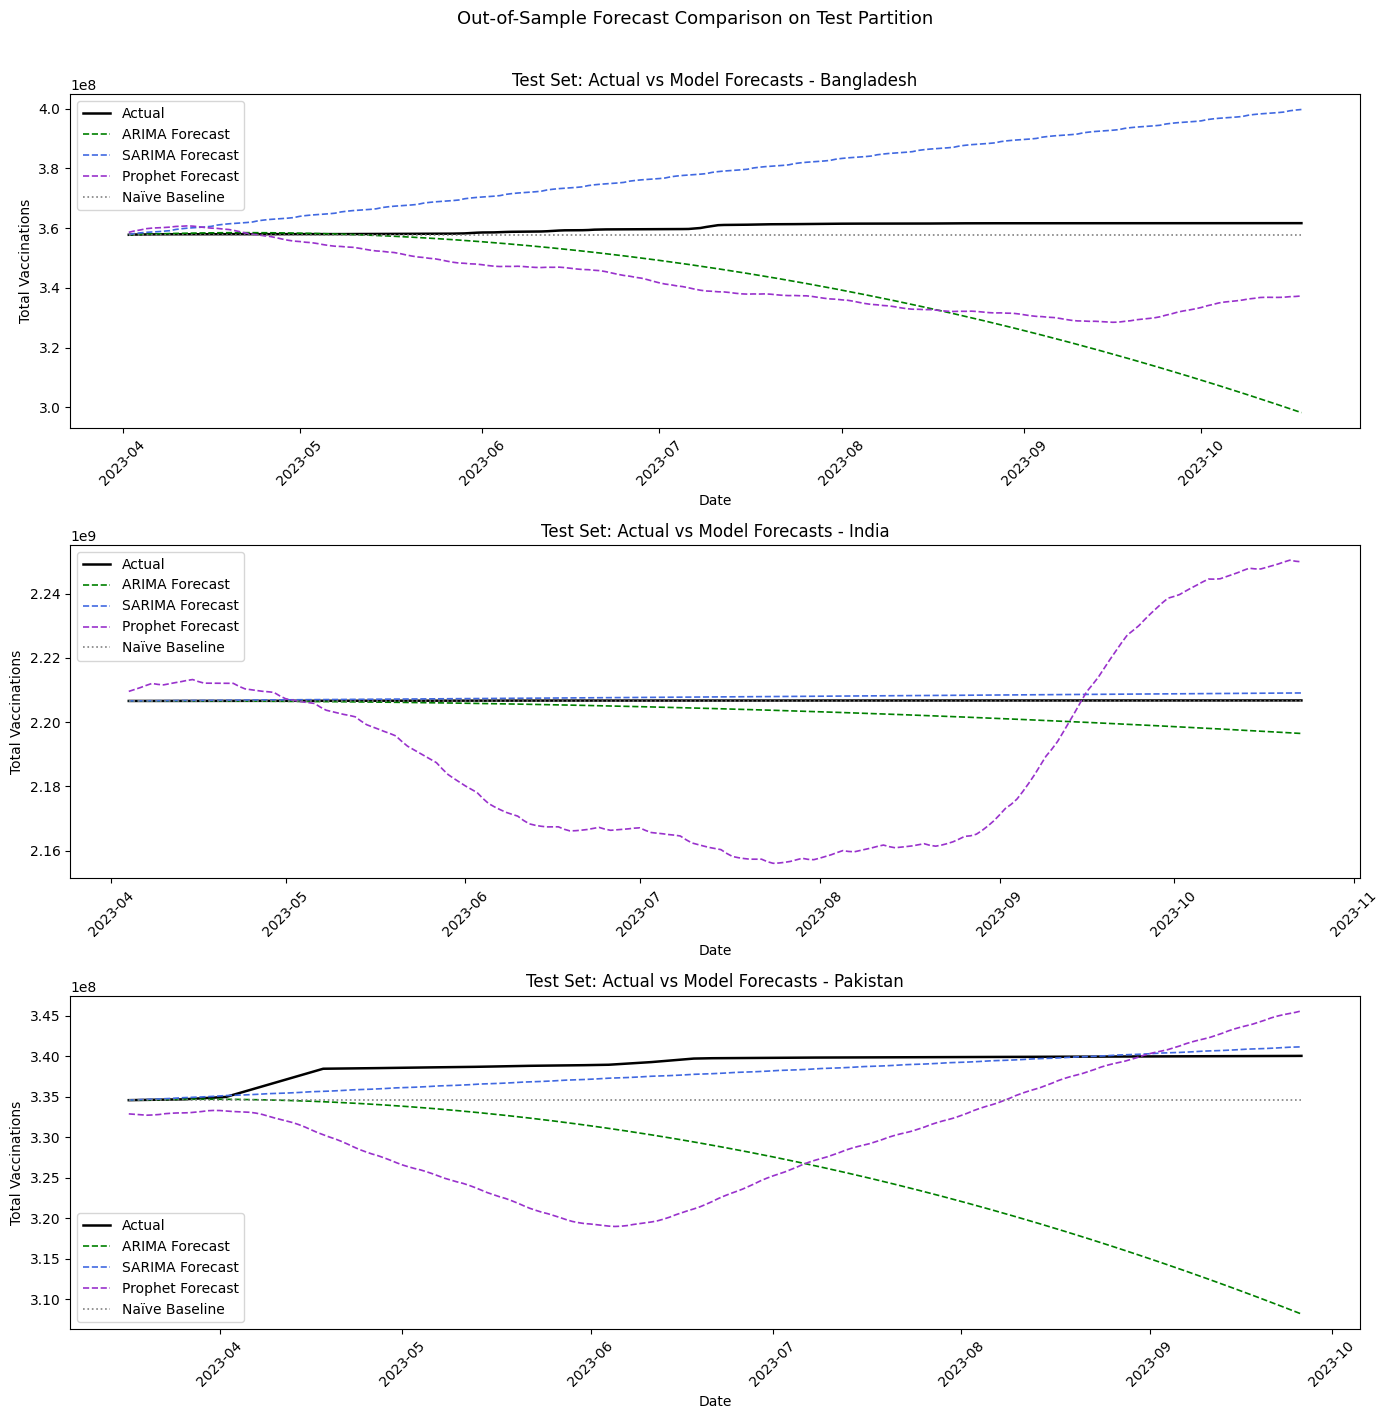

In [24]:
# Cell 21
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, country in zip(axes, COUNTRIES):
    tf  = test_forecasts[country]
    idx = tf['index']
    ax.plot(idx, tf['actual'], label='Actual',         color='black',     linewidth=1.8)
    ax.plot(idx, tf['arima'],  label='ARIMA Forecast',  color='green',     linestyle='--', linewidth=1.2)
    ax.plot(idx, tf['sarima'],  label='SARIMA Forecast',  color='royalblue', linestyle='--', linewidth=1.2)
    ax.plot(idx, tf['prophet'], label='Prophet Forecast', color='darkorchid', linestyle='--', linewidth=1.2)
    if 'naive' in tf:
        ax.plot(idx, tf['naive'], label='Naïve Baseline', color='gray',   linestyle=':',  linewidth=1.2)
    ax.set_title(f'Test Set: Actual vs Model Forecasts - {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Vaccinations')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Out-of-Sample Forecast Comparison on Test Partition', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_05_test_forecast_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


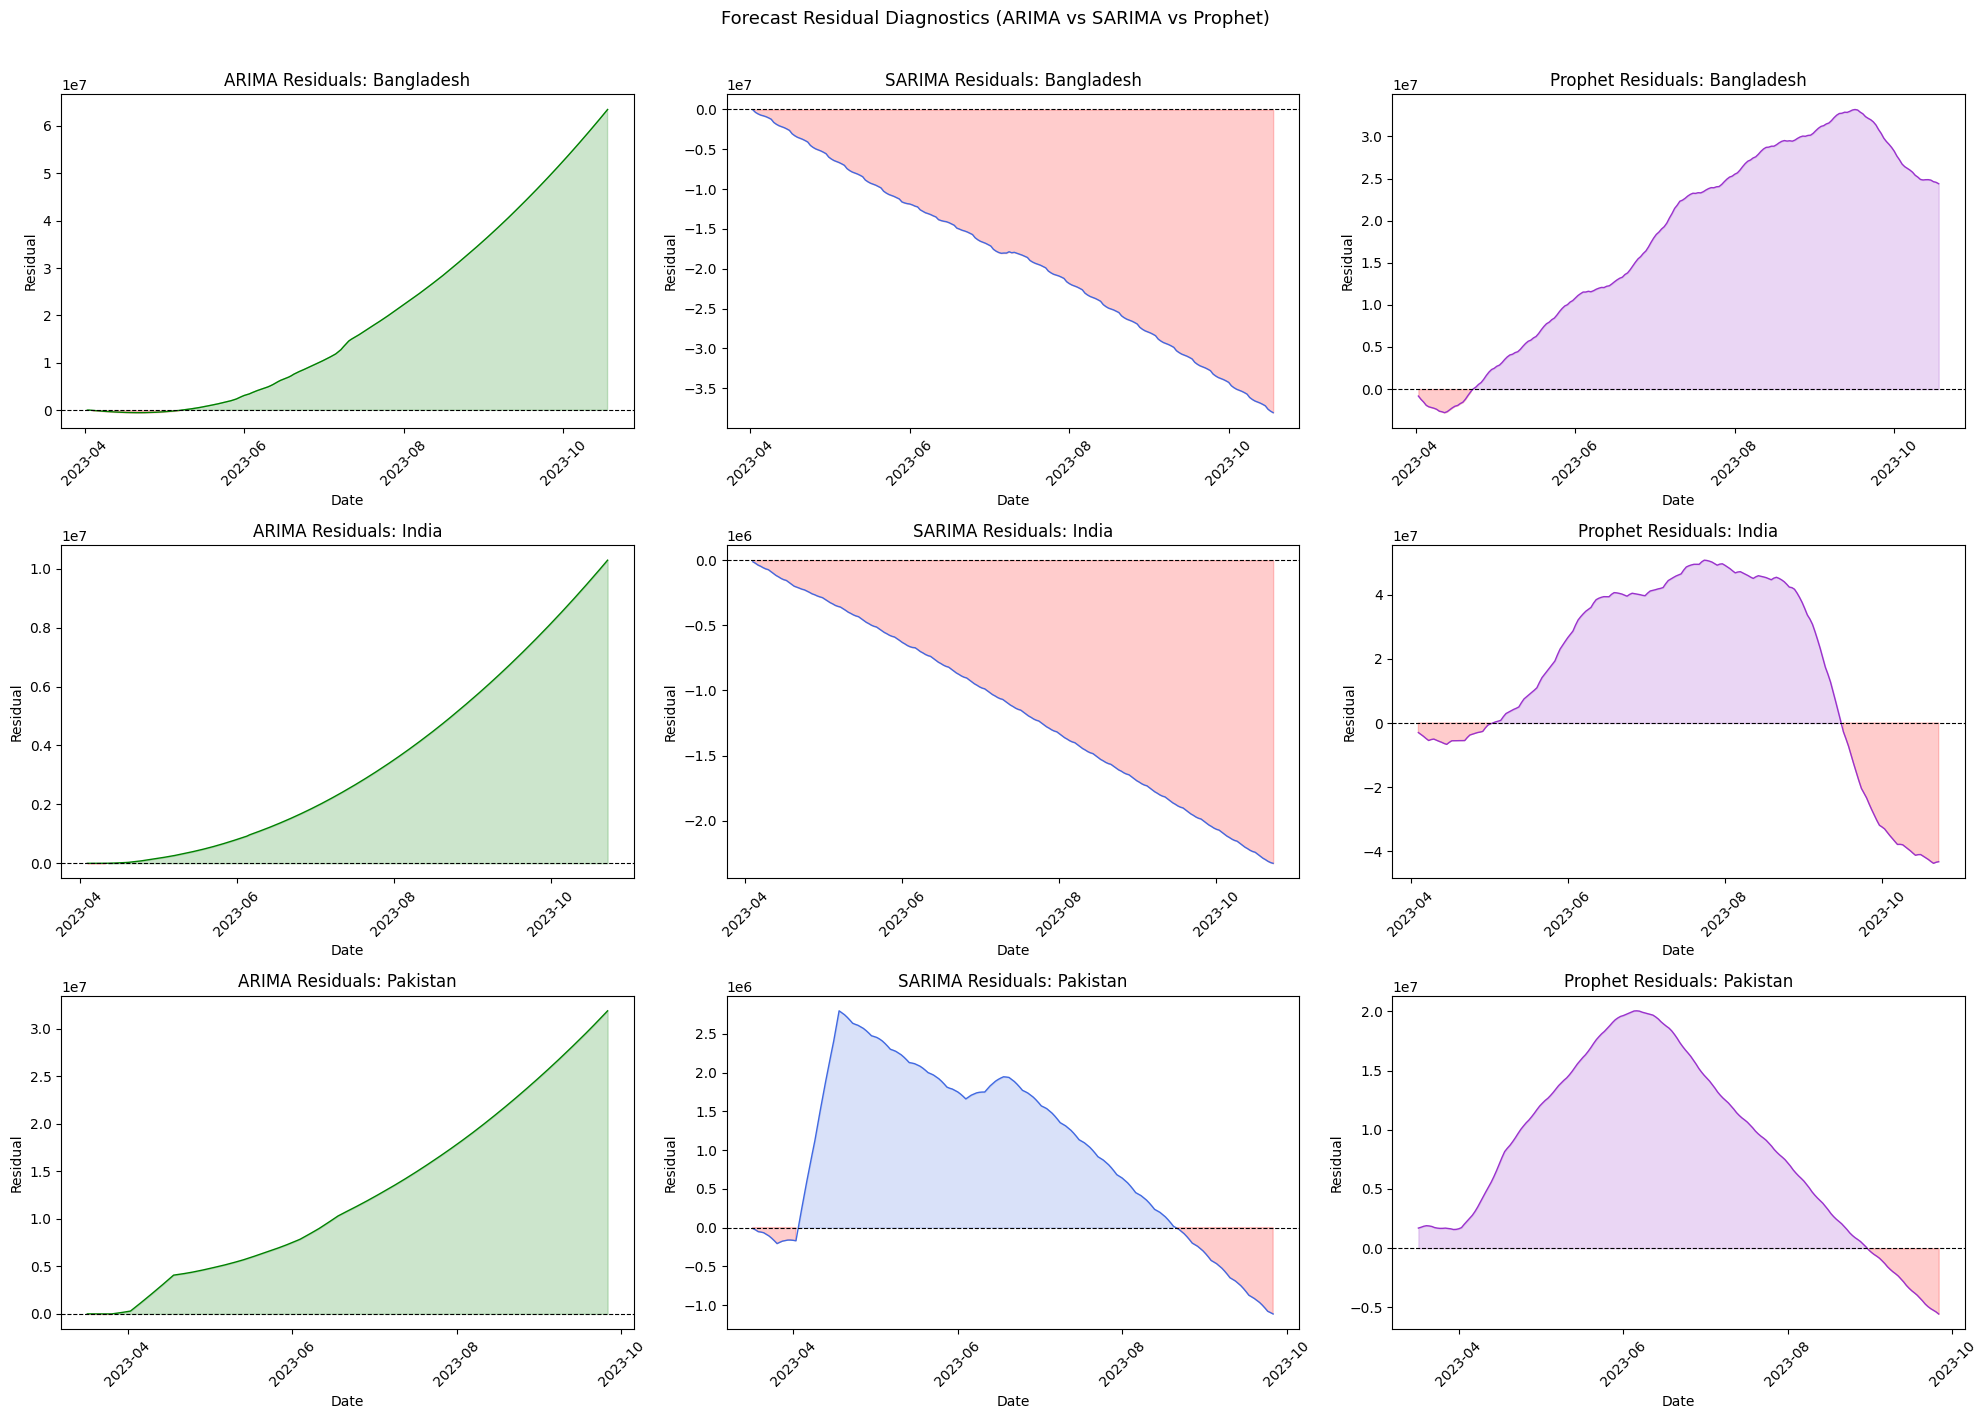

In [25]:
# Cell 22
fig, axes = plt.subplots(3, 3, figsize=(20, 14))

for i, country in enumerate(COUNTRIES):
    tf                = test_forecasts[country]
    idx               = tf['index']
    arima_residuals   = tf['actual'] - tf['arima']
    sarima_residuals  = tf['actual'] - tf['sarima']
    prophet_residuals = tf['actual'] - tf['prophet']

    for col, (residuals, color, title) in enumerate([
        (arima_residuals,   'green',      f'ARIMA Residuals: {country}'),
        (sarima_residuals,  'royalblue',  f'SARIMA Residuals: {country}'),
        (prophet_residuals, 'darkorchid', f'Prophet Residuals: {country}'),
    ]):
        ax = axes[i, col]
        ax.plot(idx, residuals, color=color, linewidth=1)
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.fill_between(idx, residuals, 0, where=(residuals > 0), alpha=0.2, color=color)
        ax.fill_between(idx, residuals, 0, where=(residuals < 0), alpha=0.2, color='red')
        ax.set_title(title)
        ax.set_xlabel('Date')
        ax.set_ylabel('Residual')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Forecast Residual Diagnostics (ARIMA vs SARIMA vs Prophet)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_06_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()


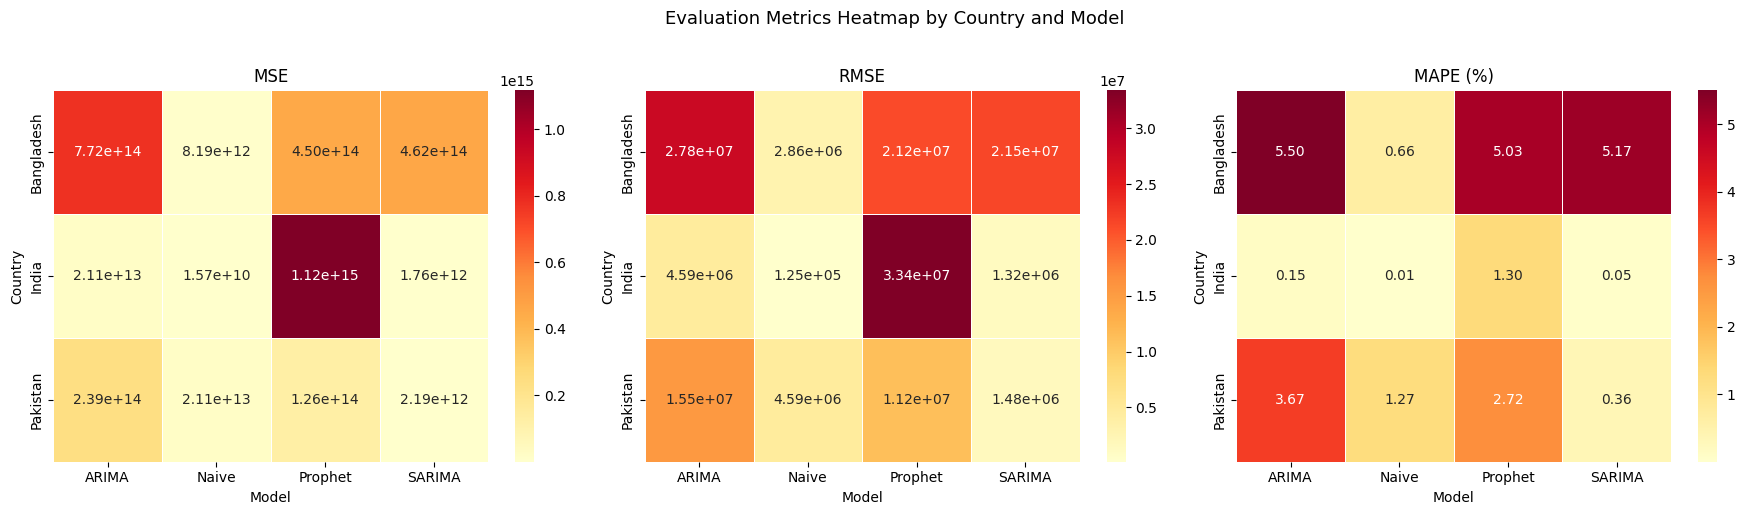

In [26]:
# Cell 23
metrics_plot = ['MSE', 'RMSE', 'MAPE (%)']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_fmt = {'MSE': '.2e', 'RMSE': '.2e', 'MAPE (%)': '.2f'}

for ax, metric in zip(axes, metrics_plot):
    pivot = metrics_df.pivot(index='Country', columns='Model', values=metric)
    sns.heatmap(
        pivot, annot=True, fmt=metric_fmt[metric], cmap='YlOrRd',
        ax=ax, linewidths=0.5, cbar=True
    )
    ax.set_title(metric)
    ax.set_xlabel('Model')
    ax.set_ylabel('Country')

plt.suptitle('Evaluation Metrics Heatmap by Country and Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_07_metrics_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# Cell 24
def _inv(arr, scaler):
    return scaler.inverse_transform(np.asarray(arr).reshape(-1, 1)).flatten()

future_forecasts = {}

for country in COUNTRIES:
    train_sc = scaled_splits[country]['train']['total_vaccinations']
    test_sc  = scaled_splits[country]['test']['total_vaccinations']
    full_sc  = pd.concat([train_sc, test_sc])
    scaler   = scalers[country]

    last_date    = country_data[country].index.max()
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=FORECAST_HORIZON,
        freq='D'
    )

    arima_full  = ARIMA(full_sc, order=arima_fits[country].order).fit()
    sarima_full = SARIMAX(
        full_sc,
        order=sarima_fits[country].order,
        seasonal_order=sarima_fits[country].seasonal_order
    ).fit(disp=False)

    arima_fc  = arima_full.get_forecast(steps=FORECAST_HORIZON).summary_frame(alpha=0.05)
    sarima_fc = sarima_full.get_forecast(steps=FORECAST_HORIZON).summary_frame(alpha=0.05)


    # Prophet: refit on full original-scale data
    full_prophet_df = (
        country_data[country]
        .reset_index()
        .rename(columns={'date': 'ds', 'total_vaccinations': 'y'})
    )
    prophet_full = Prophet(
        interval_width=0.95,
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode='additive'
    )
    prophet_full.fit(full_prophet_df)
    future_prophet_df = prophet_full.make_future_dataframe(periods=FORECAST_HORIZON, freq='D')
    prophet_future_fc = prophet_full.predict(future_prophet_df).tail(FORECAST_HORIZON)

    entry = {
        'dates'          : future_dates,
        'arima'          : _inv(arima_fc['mean'], scaler),
        'arima_lower'    : _inv(arima_fc['mean_ci_lower'], scaler),
        'arima_upper'    : _inv(arima_fc['mean_ci_upper'], scaler),
        'sarima'         : _inv(sarima_fc['mean'], scaler),
        'sarima_lower'   : _inv(sarima_fc['mean_ci_lower'], scaler),
        'sarima_upper'   : _inv(sarima_fc['mean_ci_upper'], scaler),
        'prophet'        : prophet_future_fc['yhat'].values,
        'prophet_lower'  : prophet_future_fc['yhat_lower'].values,
        'prophet_upper'  : prophet_future_fc['yhat_upper'].values,
    }

    future_forecasts[country] = entry
    print(
        f"{country}: forecast window "
        f"{future_dates[0].date()} to {future_dates[-1].date()}"
    )


Bangladesh: forecast window 2023-10-19 to 2024-04-15
India: forecast window 2023-10-24 to 2024-04-20
Pakistan: forecast window 2023-09-27 to 2024-03-24


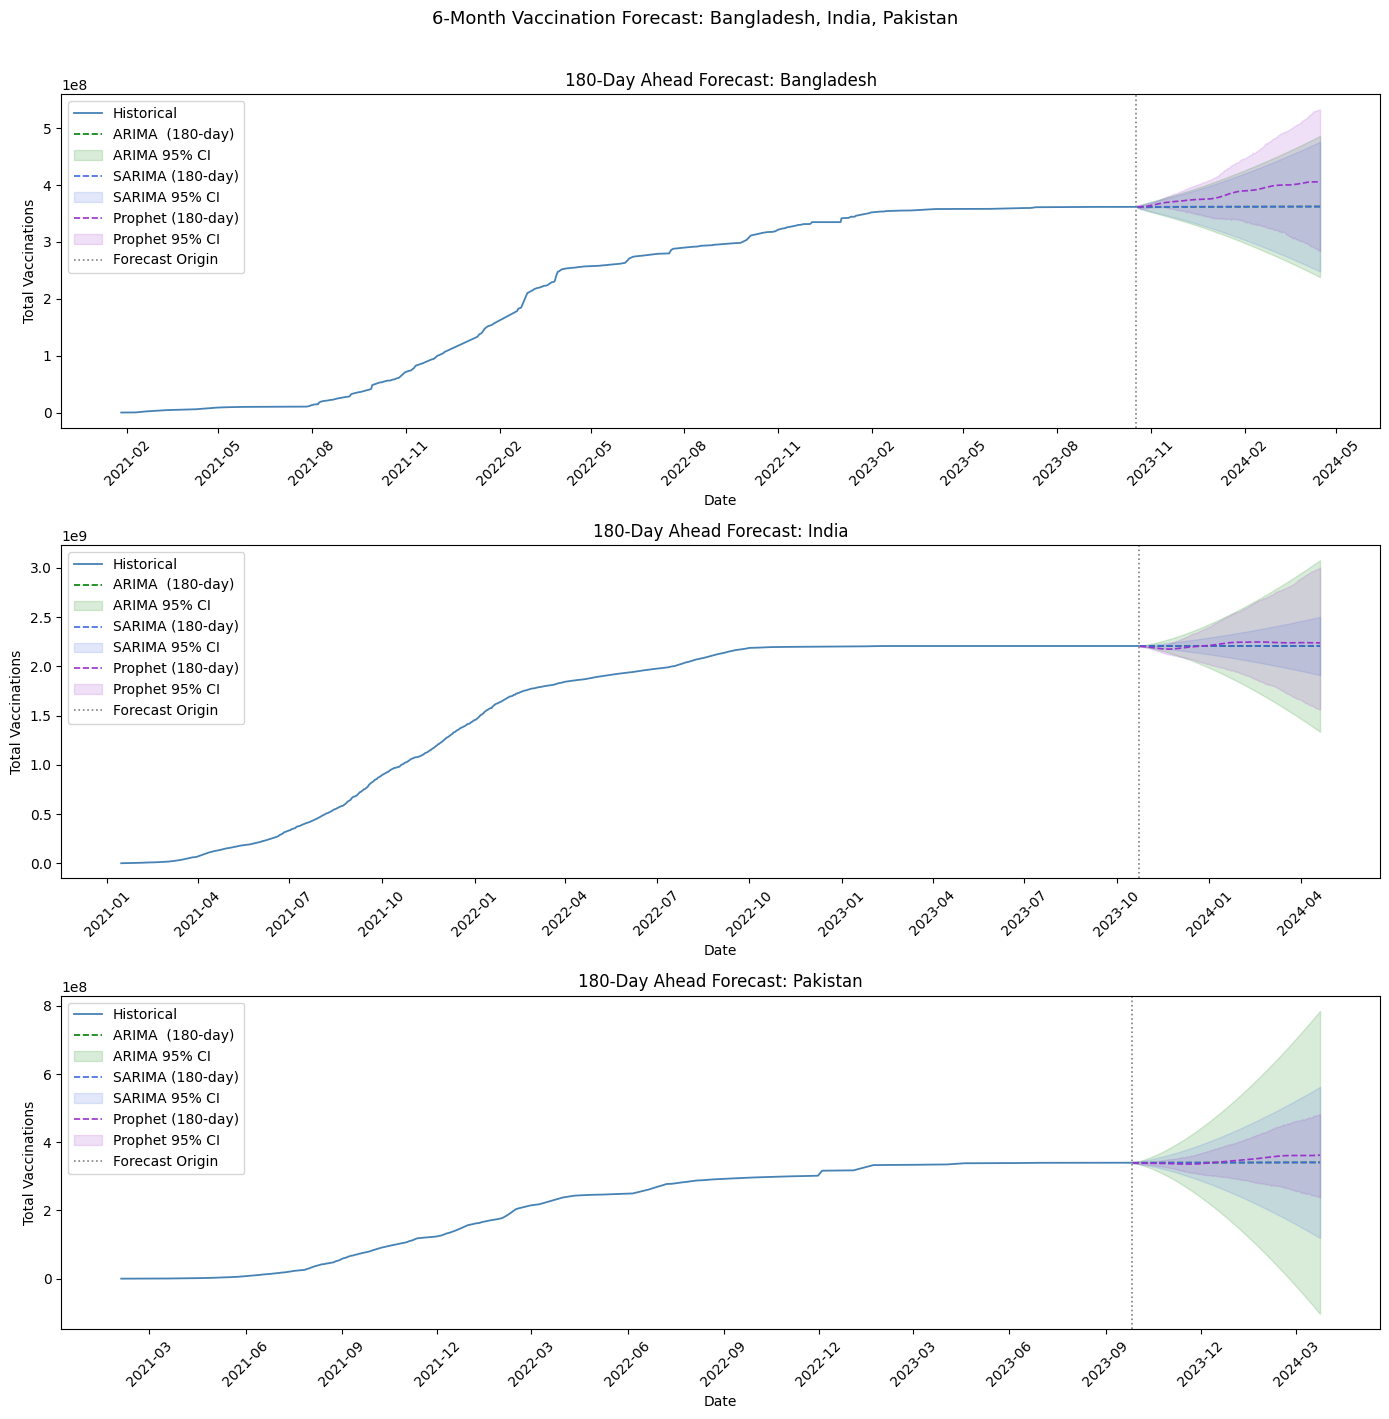

In [28]:
# Cell 25
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, country in zip(axes, COUNTRIES):
    hist = country_data[country]
    ff   = future_forecasts[country]

    ax.plot(hist.index, hist['total_vaccinations'],
            label='Historical', color='steelblue', linewidth=1.3)

    ax.plot(ff['dates'], ff['arima'],
            label='ARIMA  (180-day)', color='green', linestyle='--', linewidth=1.2)
    if 'arima_lower' in ff:
        ax.fill_between(ff['dates'], ff['arima_lower'], ff['arima_upper'],
                        color='green', alpha=0.15, label='ARIMA 95% CI')

    ax.plot(ff['dates'], ff['sarima'],
            label='SARIMA (180-day)', color='royalblue', linestyle='--', linewidth=1.2)
    if 'sarima_lower' in ff:
        ax.fill_between(ff['dates'], ff['sarima_lower'], ff['sarima_upper'],
                        color='royalblue', alpha=0.15, label='SARIMA 95% CI')

    ax.plot(ff['dates'], ff['prophet'],
            label='Prophet (180-day)', color='darkorchid', linestyle='--', linewidth=1.2)
    if 'prophet_lower' in ff:
        ax.fill_between(ff['dates'], ff['prophet_lower'], ff['prophet_upper'],
                        color='darkorchid', alpha=0.15, label='Prophet 95% CI')

    ax.axvline(x=hist.index.max(), color='gray', linestyle=':', linewidth=1.2,
               label='Forecast Origin')
    ax.set_title(f'180-Day Ahead Forecast: {country}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Vaccinations')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('6-Month Vaccination Forecast: Bangladesh, India, Pakistan', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fig_08_future_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()
